# Conditional generation (CFG) + Imputation — color digits SVHN

This notebook has two parts:

**Part 1 — Conditional generation with CFG**  
Loads the three checkpoints from `color_digits_cond_checkpoints/` (VP-Linear, VP-Cosine, VP-Exponential) and generates class-conditional samples using `CondUNetScoreModel` + `CFGWrapper` from `diffusion_lib`.

**Part 2 — Imputation**  
Loads the unconditional VP-Cosine checkpoint from `color_digits_checkpoints/` and reconstructs masked regions of real SVHN images using `ImputationSampler`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import scipy.io
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Resolve project root whether the notebook is run from notebooks_extra/ or project root
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'diffusion_lib').exists():
    PROJECT_DIR = PROJECT_DIR.parent / 'proyecto' / 'proyecto_AAIII_02_diffusion_models'
if not (PROJECT_DIR / 'diffusion_lib').exists():
    raise RuntimeError(f'Cannot locate diffusion_lib from {Path.cwd()}')
sys.path.insert(0, str(PROJECT_DIR))

from diffusion_lib import (
    VPProcess,
    LinearSchedule, CosineSchedule, ExponentialSchedule,
    CondUNetScoreModel,
    CFGWrapper,
    ImputationSampler,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Project dir:', PROJECT_DIR)
print('Device:', device)

Project dir: /Users/ivandominguez/Desktop/practicas3segundocuatri/apaut3/proyecto/proyecto_AAIII_02_diffusion_models
Device: cpu


---
## Part 1 — Conditional generation with Classifier-Free Guidance

The three conditional checkpoints were trained with the same U-Net architecture as `CondUNetScoreModel`.  
The guided score is:
$$s_\text{CFG}(x,t,y) = s_\theta(x,t,\emptyset) + w\,\bigl[s_\theta(x,t,y) - s_\theta(x,t,\emptyset)\bigr]$$

In [2]:
from diffusion_lib.processes.ve import VEProcess


COND_CKPT_DIR = PROJECT_DIR / 'color_digits_cond_checkpoints'

COND_PROCESSES = {
    'VE-Brownian':    VEProcess(sigma=25.0),
    'VP-Linear':      VPProcess(schedule=LinearSchedule()),
    'VP-Cosine':      VPProcess(schedule=CosineSchedule()),
    'VP-Exponential': VPProcess(schedule=ExponentialSchedule()),
}
T_FOR = { 'VE-Brownian': 1.0, 'VP-Linear': 1.0, 'VP-Cosine': 0.999, 'VP-Exponential': 1.0}

cond_models = {}
for name, process in COND_PROCESSES.items():
    ckpt = COND_CKPT_DIR / f'color_digits_{name}.pth'
    model = CondUNetScoreModel(marginal_prob_std=process.sigma_t, n_classes=10).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    model.eval()
    cond_models[name] = (process, model)
    print(f'Loaded {ckpt.name}')


Loaded color_digits_VE-Brownian.pth
Loaded color_digits_VP-Linear.pth
Loaded color_digits_VP-Cosine.pth
Loaded color_digits_VP-Exponential.pth


In [3]:
@torch.no_grad()
def cfg_sample(process, wrapper, n_images, T=1.0, n_steps=1500, eps=1e-3):
    """Euler-Maruyama reverse SDE with a CFGWrapper as the score."""
    img_shape = (3, 32, 32)
    x = process.prior_sample((n_images, *img_shape), device)
    dt = (eps - T) / n_steps
    t_vals = torch.linspace(T, eps, n_steps + 1, device=device)
    view = [n_images, 1, 1, 1]
    wrapper.eval()
    for i in range(n_steps):
        t = t_vals[i].expand(n_images)
        score = wrapper(x, t)
        drift = process.reverse_drift(x, t, score)
        g_t = process.diffusion_coefficient(t).view(*view)
        z = torch.randn_like(x)
        x = x + drift * dt + g_t * np.sqrt(abs(dt)) * z
    return x

### 1.1 Class grid — one row per digit, columns are independent samples

For each process we generate **N_PER_CLASS** samples per digit with guidance scale **W**.

  class 0 done
  class 1 done
  class 2 done
  class 3 done
  class 4 done
  class 5 done
  class 6 done
  class 7 done
  class 8 done
  class 9 done


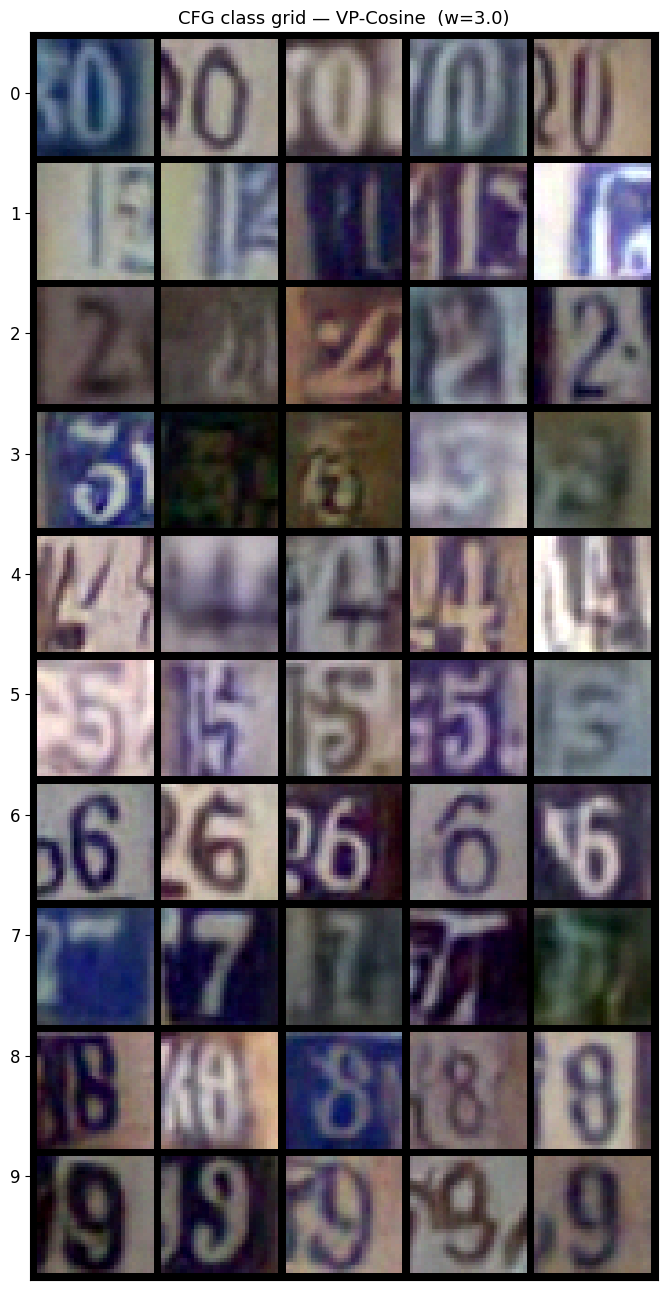

In [4]:
N_PER_CLASS = 5
W           = 3.0
PROC_SHOW   = 'VP-Cosine'

process, model = cond_models[PROC_SHOW]
T = T_FOR[PROC_SHOW]

rows = []
for y in range(10):
    wrapper = CFGWrapper(model, class_label=y, cfg_scale=W)
    sams = cfg_sample(process, wrapper, N_PER_CLASS, T=T).cpu().clamp(0, 1)
    rows.append(sams)
    print(f'  class {y} done')

grid_tensor = torch.cat(rows, dim=0)   # [100, 3, 32, 32]
grid = make_grid(grid_tensor, nrow=N_PER_CLASS)

fig, ax = plt.subplots(figsize=(N_PER_CLASS * 1.2 + 1, 13))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_yticks(np.arange(10) * 33 + 16)
ax.set_yticklabels(list(range(10)), fontsize=12)
ax.set_xticks([])
ax.set_title(f'CFG class grid — {PROC_SHOW}  (w={W})', fontsize=13)
plt.tight_layout()
out_dir = PROJECT_DIR / 'Figuras'; out_dir.mkdir(exist_ok=True)
fig.savefig(out_dir / 'cfg_class_grid.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.2 Guidance scale ablation

Same digit, same process — sweep **w** from 0 (unconditional) to 7.  
High w → sharper class identity, less diversity.

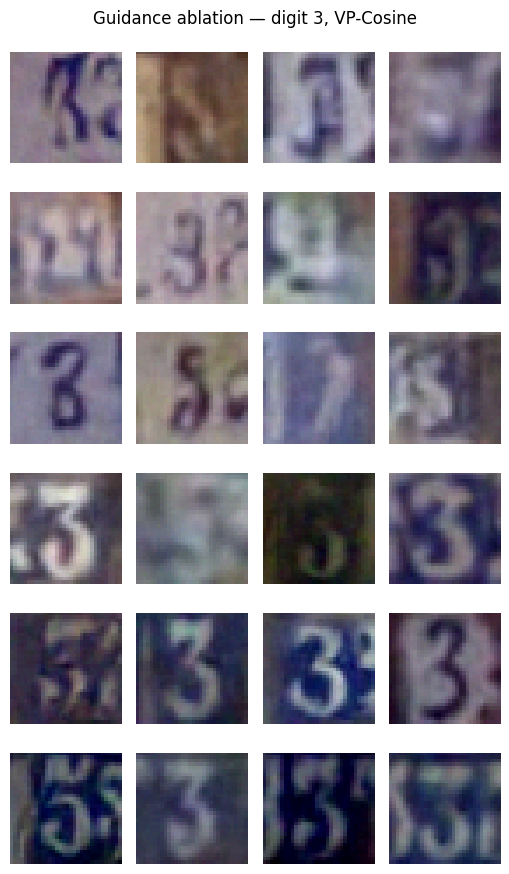

In [5]:
DIGIT       = 3
W_SWEEP     = [0.0, 1.0, 2.0, 3.0, 5.0, 7.0]
N_SAMPLES   = 4
PROC_SHOW   = 'VP-Cosine'

process, model = cond_models[PROC_SHOW]
T = T_FOR[PROC_SHOW]

fig, axes = plt.subplots(len(W_SWEEP), N_SAMPLES,
                          figsize=(N_SAMPLES * 1.3, len(W_SWEEP) * 1.5))
for row_i, w in enumerate(W_SWEEP):
    wrapper = CFGWrapper(model, class_label=DIGIT, cfg_scale=w)
    sams = cfg_sample(process, wrapper, N_SAMPLES, T=T).cpu().clamp(0, 1)
    for col_i in range(N_SAMPLES):
        axes[row_i, col_i].imshow(sams[col_i].permute(1, 2, 0).numpy())
        axes[row_i, col_i].axis('off')
    axes[row_i, 0].set_ylabel(f'w={w}', rotation=0, labelpad=35, fontsize=11)

fig.suptitle(f'Guidance ablation — digit {DIGIT}, {PROC_SHOW}', fontsize=12)
plt.tight_layout()
fig.savefig(out_dir / 'cfg_ablation_w.png', bbox_inches='tight', dpi=150)
plt.show()

### 1.3 Process comparison — same digit, all three processes

Row = process (Linear / Cosine / Exponential schedule), columns = independent samples.

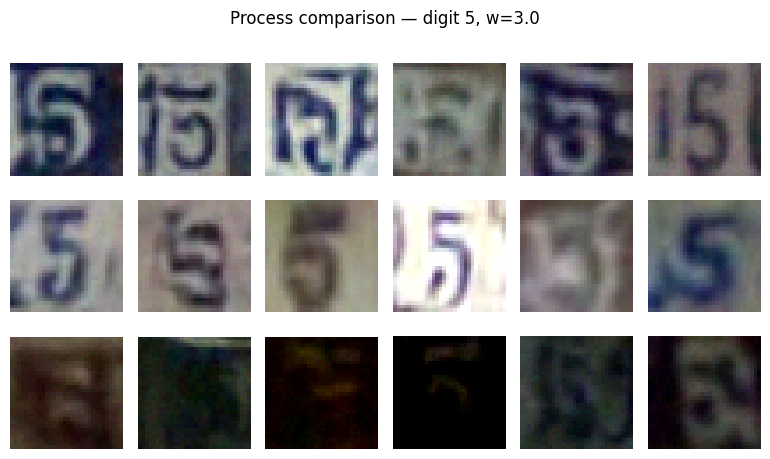

In [6]:
DIGIT  = 5
W      = 3.0
N_COLS = 6

# Mostrar solo los modelos VP (Linear, Cosine, Exponential)
vp_models = {k: v for k, v in cond_models.items() if k.startswith("VP")}
n_rows = len(vp_models)

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * 1.3, n_rows * 1.6))
if n_rows == 1:
    axes = axes[np.newaxis, :]  # asegurar siempre 2D

for row_i, (pname, (process, model)) in enumerate(vp_models.items()):
    T = T_FOR[pname]
    wrapper = CFGWrapper(model, class_label=DIGIT, cfg_scale=W)
    sams = cfg_sample(process, wrapper, N_COLS, T=T).cpu().clamp(0, 1)
    for col_i in range(N_COLS):
        axes[row_i, col_i].imshow(sams[col_i].permute(1, 2, 0).numpy())
        axes[row_i, col_i].axis("off")
    axes[row_i, 0].set_ylabel(pname, rotation=0, labelpad=80, fontsize=10)

fig.suptitle(f"Process comparison — digit {DIGIT}, w={W}", fontsize=12)
plt.tight_layout()
fig.savefig(out_dir / "cfg_process_comparison.png", bbox_inches="tight", dpi=150)
plt.show()


---
## Part 2 — Imputation

We load the **unconditional** VP-Cosine model and use `ImputationSampler` to reconstruct masked-out regions of real SVHN images.

**Mask convention:** `mask = 1` → known pixel (preserved), `mask = 0` → unknown (inferred).

In [7]:
from diffusion_lib import UNetScoreModelColor as ScoreNetColor

UNCOND_CKPT_DIR = PROJECT_DIR / 'color_digits_checkpoints'

process_imp = VPProcess(schedule=CosineSchedule())
score_model = ScoreNetColor(marginal_prob_std=process_imp.sigma_t).to(device)
ckpt_path   = UNCOND_CKPT_DIR / 'color_digits_VP-Cosine.pth'
score_model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
score_model.eval()
print(f'Loaded: {ckpt_path.name}')

Loaded: color_digits_VP-Cosine.pth


In [8]:
# Load a small batch of real SVHN images
DATA_PATH = PROJECT_DIR / 'data' / 'MNIST' / 'raw' / 'train_32x32.mat'
mat = scipy.io.loadmat(str(DATA_PATH))
X_all = np.transpose(mat['X'], (3, 2, 0, 1)).astype(np.float32) / 255.0  # (N, 3, 32, 32)

N_IMGS  = 6
indices = np.random.choice(len(X_all), N_IMGS, replace=False)
x_real  = torch.from_numpy(X_all[indices])   # (N_IMGS, 3, 32, 32)
print(f'Loaded {N_IMGS} images from SVHN  |  shape: {x_real.shape}')

Loaded 6 images from SVHN  |  shape: torch.Size([6, 3, 32, 32])


In [9]:
def make_mask(shape, kind):
    """Return a binary mask (B,1,H,W). 1=known, 0=infer."""
    B, C, H, W = shape
    m = torch.ones(B, 1, H, W)
    if kind == 'horizontal_band':
        m[:, :, H // 3 : 2 * H // 3, :] = 0.0
    elif kind == 'center_square':
        m[:, :, H // 4 : 3 * H // 4, W // 4 : 3 * W // 4] = 0.0
    elif kind == 'right_half':
        m[:, :, :, W // 2 :] = 0.0
    elif kind == 'random_50pct':
        m = (torch.rand(B, 1, H, W) > 0.5).float()
    return m

MASK_TYPES = ['horizontal_band', 'center_square', 'right_half', 'random_50pct']

In [10]:
# n_resample > 1 activa el ciclado RePaint: en cada paso reverse se re-noisea
# la imagen y se vuelve a aplicar el step, mejorando la coherencia en la frontera.
# n_steps mayor reduce el error de discretización de la SDE.
N_STEPS_IMP  = 1000  # más pasos → menor error de discretización
N_RESAMPLE   = 1     # sin ciclado RePaint (causaba divergencia con máscaras grandes)

sampler = ImputationSampler(n_resample=N_RESAMPLE)

results = {}
for kind in MASK_TYPES:
    print(f"Inpainting with mask: {kind} ...", end=" ", flush=True)
    mask = make_mask(x_real.shape, kind)
    x_filled = sampler.inpaint(
        score_model=score_model,
        process=process_imp,
        x_known=x_real,
        mask=mask,
        n_steps=N_STEPS_IMP,
        device=device,
        T=0.999,
    )
    results[kind] = (mask.cpu(), x_filled.cpu())
    print("done")


Inpainting with mask: horizontal_band ... done
Inpainting with mask: center_square ... done
Inpainting with mask: right_half ... done
Inpainting with mask: random_50pct ... done


### 2.1 Visualisation: original / masked / reconstructed

Three columns per mask type; rows show each image in the batch.

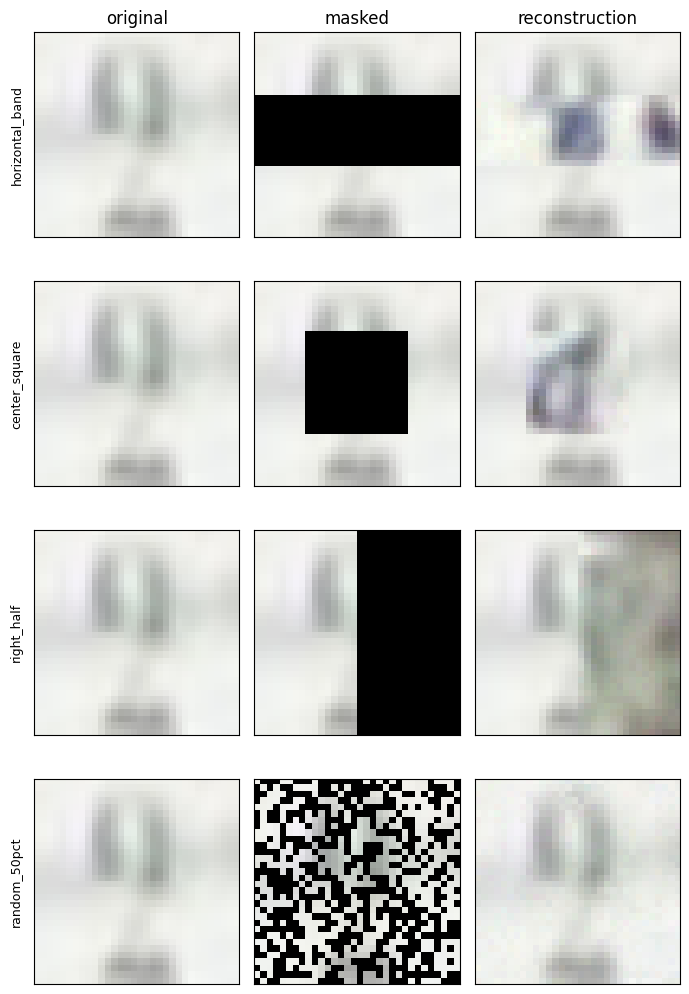

In [11]:
IDX = 0    # which image from the batch to display

fig, axes = plt.subplots(len(MASK_TYPES), 3,
                          figsize=(7, len(MASK_TYPES) * 2.6))
for i, kind in enumerate(MASK_TYPES):
    mask, x_filled = results[kind]
    masked = x_real[IDX] * mask[IDX]   # broadcast 1-channel mask → 3 channels

    axes[i, 0].imshow(x_real[IDX].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i, 1].imshow(masked.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i, 2].imshow(x_filled[IDX].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i, 0].set_ylabel(kind, rotation=90, fontsize=9, labelpad=8)
    for j in range(3):
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])

axes[0, 0].set_title('original')
axes[0, 1].set_title('masked')
axes[0, 2].set_title('reconstruction')
plt.tight_layout()
fig.savefig(out_dir / 'imputation_masks.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.2 Diversity — multiple reconstructions for the same mask

Because the sampler is stochastic, running it multiple times on the same masked image yields different plausible completions.  
This illustrates that the inpainting problem is ill-posed.

  reconstruction 1/6... done
  reconstruction 2/6... done
  reconstruction 3/6... done
  reconstruction 4/6... done
  reconstruction 5/6... done
  reconstruction 6/6... done


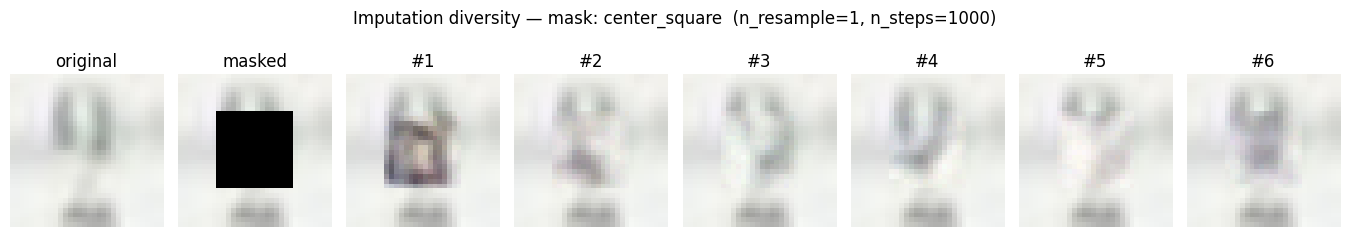

In [12]:
N_REC  = 6
KIND   = "center_square"
IMG_I  = 0

x_one = x_real[IMG_I : IMG_I + 1].to(device)
mask  = make_mask(x_one.shape, KIND).to(device)

recs = []
for i in range(N_REC):
    print(f"  reconstruction {i + 1}/{N_REC}...", end=" ", flush=True)
    x_filled = sampler.inpaint(
        score_model=score_model, process=process_imp,
        x_known=x_one, mask=mask,
        n_steps=N_STEPS_IMP, device=device, T=0.999,
    )
    recs.append(x_filled[0].cpu())
    print("done")

fig, axes = plt.subplots(1, N_REC + 2, figsize=((N_REC + 2) * 1.7, 2.4))
axes[0].imshow(x_one[0].cpu().permute(1, 2, 0).clamp(0, 1).numpy())
axes[0].set_title("original")
masked_show = (x_one[0] * mask[0]).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
axes[1].imshow(masked_show)
axes[1].set_title("masked")
for i, rec in enumerate(recs):
    axes[i + 2].imshow(rec.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[i + 2].set_title(f"#{i + 1}")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"Imputation diversity — mask: {KIND}  (n_resample={N_RESAMPLE}, n_steps={N_STEPS_IMP})", y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(out_dir / "imputation_diversity.png", bbox_inches="tight", dpi=150)
plt.show()


### 2.3 Sanity check — known pixels must be preserved exactly

`ImputationSampler` pins the known pixels at t≈0, so `mask * x_filled` should equal `mask * x_real` up to floating-point precision.

In [13]:
for kind in MASK_TYPES:
    mask_cpu, x_filled_cpu = results[kind]
    residual = ((mask_cpu * x_filled_cpu) - (mask_cpu * x_real)).abs().max().item()
    n_known  = int(mask_cpu.sum().item())
    print(f'{kind:<20}  max error in known pixels: {residual:.2e}   known px: {n_known}')

horizontal_band       max error in known pixels: 0.00e+00   known px: 4032
center_square         max error in known pixels: 0.00e+00   known px: 4608
right_half            max error in known pixels: 0.00e+00   known px: 3072
random_50pct          max error in known pixels: 0.00e+00   known px: 3085
